In [ ]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [ ]:
class Encoder(nn.Module):
    def __init__(self, latent_dim=128):
        super(Encoder, self).__init__()
        # Input: 3 x 64 x 64
        # Using stride=2 to halve the spatial dimensions at each step
        self.conv1 = nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1)   # Output: 32 x 32 x 32
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1)  # Output: 64 x 16 x 16
        self.conv3 = nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1) # Output: 128 x 8 x 8
        self.conv4 = nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1)# Output: 256 x 4 x 4
        
        self.flatten_size = 256 * 4 * 4
        
        # Parallel layers for Mean and Log-Variance (Question 1.1)
        self.fc_mu = nn.Linear(self.flatten_size, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_size, latent_dim)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        
        x = x.view(-1, self.flatten_size) # Flatten
        
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

In [ ]:
class Decoder(nn.Module):
    def __init__(self, latent_dim=128):
        super(Decoder, self).__init__()
        self.flatten_size = 256 * 4 * 4
        
        # Project latent vector back to spatial dimensions
        self.fc = nn.Linear(latent_dim, self.flatten_size)
        
        # Upsampling using ConvTranspose2d
        self.deconv1 = nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1) # Output: 128 x 8 x 8
        self.deconv2 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1)  # Output: 64 x 16 x 16
        self.deconv3 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)   # Output: 32 x 32 x 32
        self.deconv4 = nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1)    # Output: 3 x 64 x 64
        
    def forward(self, z):
        x = F.relu(self.fc(z))
        x = x.view(-1, 256, 4, 4) # Unflatten
        
        x = F.relu(self.deconv1(x))
        x = F.relu(self.deconv2(x))
        x = F.relu(self.deconv3(x))
        
        # Ending with Sigmoid as requested for Tiny-ImageNet-10
        reconstruction = torch.sigmoid(self.deconv4(x)) 
        return reconstruction

In [ ]:
class CVAE(nn.Module):
    def __init__(self, latent_dim=128):
        super(CVAE, self).__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)
        
    def reparameterize(self, mu, logvar):
        """Question 1.1: The Reparameterization Trick"""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
        
    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decoder(z)
        return reconstruction, mu, logvar

In [2]:
def vae_loss_function(recon_x, x, mu, logvar, kld_weight=1.0):
    # Combines Reconstruction Loss (MSE or BCE) with KLD.
    # Reconstruction loss (MSE is often more stable for RGB images than BCE)
    # reduction='sum' sums over the batch, meaning we need to average it later

    RECON = F.mse_loss(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    total_loss = RECON + (kld_weight * KLD)
    
    return total_loss, RECON, KLD

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])
data_dir = 'tiny-imagenet-200/train' 
full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)
indices_to_keep = [i for i, (_, class_idx) in enumerate(full_dataset.samples) if class_idx < 10]
tiny_dataset_10 = Subset(full_dataset, indices_to_keep)
dataloader = DataLoader(tiny_dataset_10, batch_size=64, shuffle=True, num_workers=2)

print(f"Loaded {len(tiny_dataset_10)} images across 10 classes.")

Using device: cpu
Loaded 5000 images across 10 classes.


In [4]:
# Initialize Model and Optimizer
model = CVAE(latent_dim=128).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epoch_total_losses = []
epoch_recon_losses = []
epoch_kld_losses = []

num_epochs = 20
kld_weight = 1.0 

print("Starting Training...")
for epoch in range(num_epochs):
    model.train()
    
    train_loss = 0.0
    train_recon = 0.0
    train_kld = 0.0
    
    for batch_idx, (images, _) in enumerate(dataloader):
        images = images.to(device)
        
        # Forward pass
        recon_images, mu, logvar = model(images)
        
        # Calculate loss
        loss, recon, kld = vae_loss_function(recon_images, images, mu, logvar, kld_weight)
        
        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Accumulate losses (divide by batch size to get average per image in the batch)
        train_loss += loss.item() / len(images)
        train_recon += recon.item() / len(images)
        train_kld += kld.item() / len(images)
        
    # Calculate average loss per epoch
    avg_loss = train_loss / len(dataloader)
    avg_recon = train_recon / len(dataloader)
    avg_kld = train_kld / len(dataloader)
    
    epoch_total_losses.append(avg_loss)
    epoch_recon_losses.append(avg_recon)
    epoch_kld_losses.append(avg_kld)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] | Total Loss: {avg_loss:.4f} | Recon: {avg_recon:.4f} | KLD: {avg_kld:.4f}")

print("Training Complete!")

Starting Training...
Epoch [1/20] | Total Loss: 686.6604 | Recon: 676.2711 | KLD: 10.3893
Epoch [2/20] | Total Loss: 528.3768 | Recon: 507.6385 | KLD: 20.7383
Epoch [3/20] | Total Loss: 458.6775 | Recon: 429.8875 | KLD: 28.7900
Epoch [4/20] | Total Loss: 438.4460 | Recon: 405.7333 | KLD: 32.7127
Epoch [5/20] | Total Loss: 421.4465 | Recon: 386.3537 | KLD: 35.0929
Epoch [6/20] | Total Loss: 396.7546 | Recon: 359.5294 | KLD: 37.2253
Epoch [7/20] | Total Loss: 380.8089 | Recon: 343.5739 | KLD: 37.2350
Epoch [8/20] | Total Loss: 372.8672 | Recon: 334.8494 | KLD: 38.0178
Epoch [9/20] | Total Loss: 368.5746 | Recon: 330.5382 | KLD: 38.0364
Epoch [10/20] | Total Loss: 360.5999 | Recon: 322.4279 | KLD: 38.1720
Epoch [11/20] | Total Loss: 353.1675 | Recon: 314.0597 | KLD: 39.1078
Epoch [12/20] | Total Loss: 348.8461 | Recon: 309.0988 | KLD: 39.7473
Epoch [13/20] | Total Loss: 344.4261 | Recon: 304.1868 | KLD: 40.2394
Epoch [14/20] | Total Loss: 341.5563 | Recon: 301.1207 | KLD: 40.4356
Epoch [1

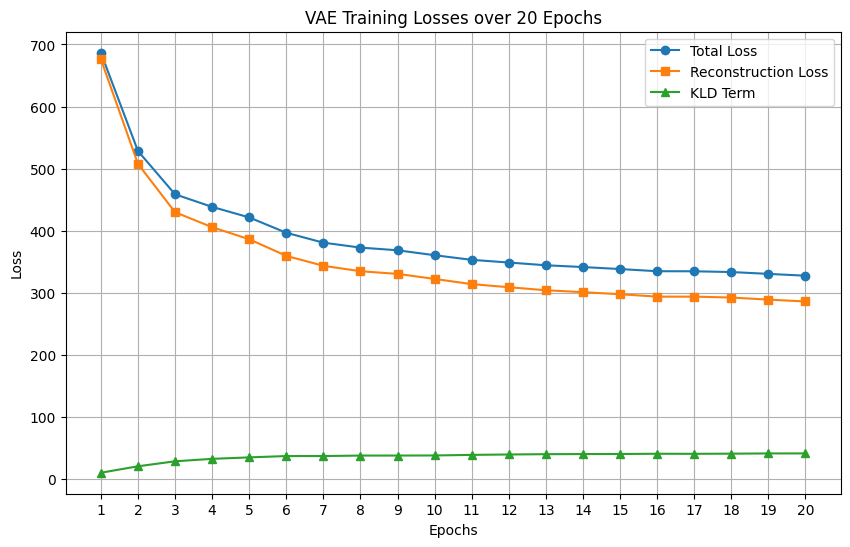

In [5]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, epoch_total_losses, label='Total Loss', marker='o')
plt.plot(epochs, epoch_recon_losses, label='Reconstruction Loss', marker='s')
plt.plot(epochs, epoch_kld_losses, label='KLD Term', marker='^')

plt.title('VAE Training Losses over 20 Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(epochs)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def generate_latent_walk(encoder, decoder, image_1, image_2, device='cpu'):
    encoder.eval()
    decoder.eval()
    
    image_1 = image_1.unsqueeze(0).to(device)
    image_2 = image_2.unsqueeze(0).to(device)

    with torch.no_grad():
        # The encoder outputs both mean (mu) and log-variance. We use mu.
        mu_1, _ = encoder(image_1)
        mu_2, _ = encoder(image_2)
        
        z_1 = mu_1.squeeze()
        z_2 = mu_2.squeeze()

        # 2. Create 10 steps of alpha from 0 to 1
        alphas = torch.linspace(0, 1, steps=10).to(device)
        interpolated_images = []

        # 3. Interpolate and Decode
        for alpha in alphas:
            # Calculate the new latent vector
            z_new = alpha * z_1 + (1 - alpha) * z_2
            
            # Reshape z_new to match the decoder's expected input shape 
            z_input = z_new.unsqueeze(0) 
            
            # Pass through the decoder
            reconstructed_img = decoder(z_input)
            interpolated_images.append(reconstructed_img.squeeze().cpu())

    fig, axes = plt.subplots(1, 10, figsize=(20, 3))
    for i, ax in enumerate(axes):
        img = interpolated_images[i].permute(1, 2, 0).numpy()
        
        ax.imshow(np.clip(img, 0, 1))
        ax.axis('off')
        ax.set_title(f'α = {alphas[i].item():.1f}')

    plt.suptitle("Latent Space Walk: Class A to Class B", fontsize=16)
    plt.tight_layout()
    plt.show()

Walking from Class 4 to Class 9...


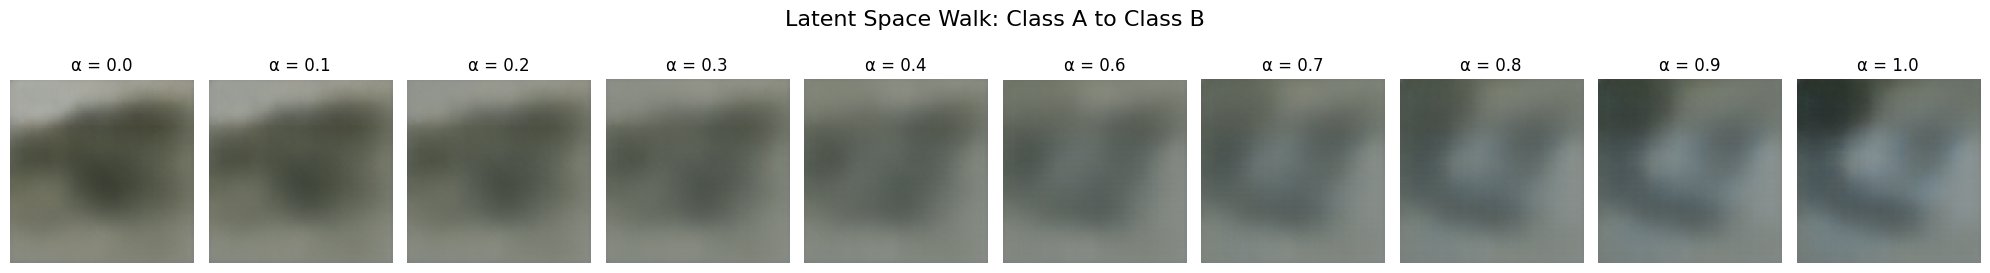

In [7]:
dataiter = iter(dataloader)
images, labels = next(dataiter)

tiny_img_A = images[0]
tiny_img_B = images[-1]
print(f"Walking from Class {labels[0].item()} to Class {labels[-1].item()}...")
generate_latent_walk(model.encoder, model.decoder, tiny_img_A, tiny_img_B, device=device)